## This notebook plots the TDN - TLN and TDN - C relation 
For a neutron star with a polytrope EOS with $n = 1$

In [74]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import hyp2f1
from tqdm import tqdm

BASE = Path.cwd().resolve().parent  # .../high_bg_order_sol
if BASE.name != 'high_bg_order_sol':
    BASE = Path.cwd().resolve()

CFG_PATH = BASE / 'config' / 'h_eps_config.pkl'
with open(CFG_PATH, 'rb') as f:
    cfg = pickle.load(f)

h_tok = str(cfg['h'])
eps_tok = str(cfg['eps'])
target_dir = BASE / 'numpy_grid' / f'h{h_tok}_eps{eps_tok}'
u01_dir = target_dir / 'U01Grids'

print('BASE      :', BASE)
print('target_dir:', target_dir)
print('u01_dir   :', u01_dir)


BASE      : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol
target_dir: /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3
u01_dir   : /Users/sztk.ch/Work/grad-school/Research/TLN-TDN Project/Programs/Equation Solver/high_bg_order_sol/numpy_grid/h1e-4_eps1e-3/U01Grids


In [75]:
# Load background radius grid
r_path = target_dir / f'RGrid_h{h_tok}_eps{eps_tok}.pkl'
PM_path = target_dir / f'PMSolGrid_h{h_tok}_eps{eps_tok}.pkl'
E0I0_path = target_dir / f'E0I0_from_u00_h{h_tok}_eps{eps_tok}.pkl'

if not r_path.exists():
    alt = target_dir / f'Rgrid_h{h_tok}_eps{eps_tok}.pkl'
    if alt.exists():
        r_path = alt

with open(r_path, 'rb') as f:
    RGrid = pickle.load(f)
with open(PM_path, 'rb') as f:
    PMSol_Grid = pickle.load(f)
with open(E0I0_path, 'rb') as f:
    E0I0Sol = pickle.load(f)
with open(u01_dir / f'H01Match_h{h_tok}_eps{eps_tok}.pkl', 'rb') as f:
    I2Sol = pickle.load(f)

n_models = len(RGrid)
print('n_models:', n_models)
n_plot = min(20, n_models)

/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_19482/665405585.py:14: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  PMSol_Grid = pickle.load(f)


n_models: 25


In [76]:
def K2(C, R, hR, DhR):
    y = R * DhR / hR
    term0 = (8/5) * (C**5) * (1 - 2*(C**2)) * (2 + 2*C*(y-1) - y)
    term1 = 2*C * (6 - 3*y + 3*C*(5*y - 8))
    term2 = 4*(C**3) * (13 - 11*y + C*(3*y - 2) + 2*(C**2)*(1 + y))
    term3 = 3*(1 - 2*C)**2 * (2 - y + 2*C*(y - 1)) * np.log(1 - 2*C)
    return term0 / (term1 + term2 + term3)


def Love(k2, C):
    return (2/3) * k2 / (C**5)

def TDN(C, I2, E0):
    return (1/2) * (C**5) * (I2/E0)


def CompactPRD(k2, a=(0.371, -0.0391, 0.001056)):
    lnk2 = np.log(k2)
    return a[0] + a[1]*lnk2 + a[2]*(lnk2**2)


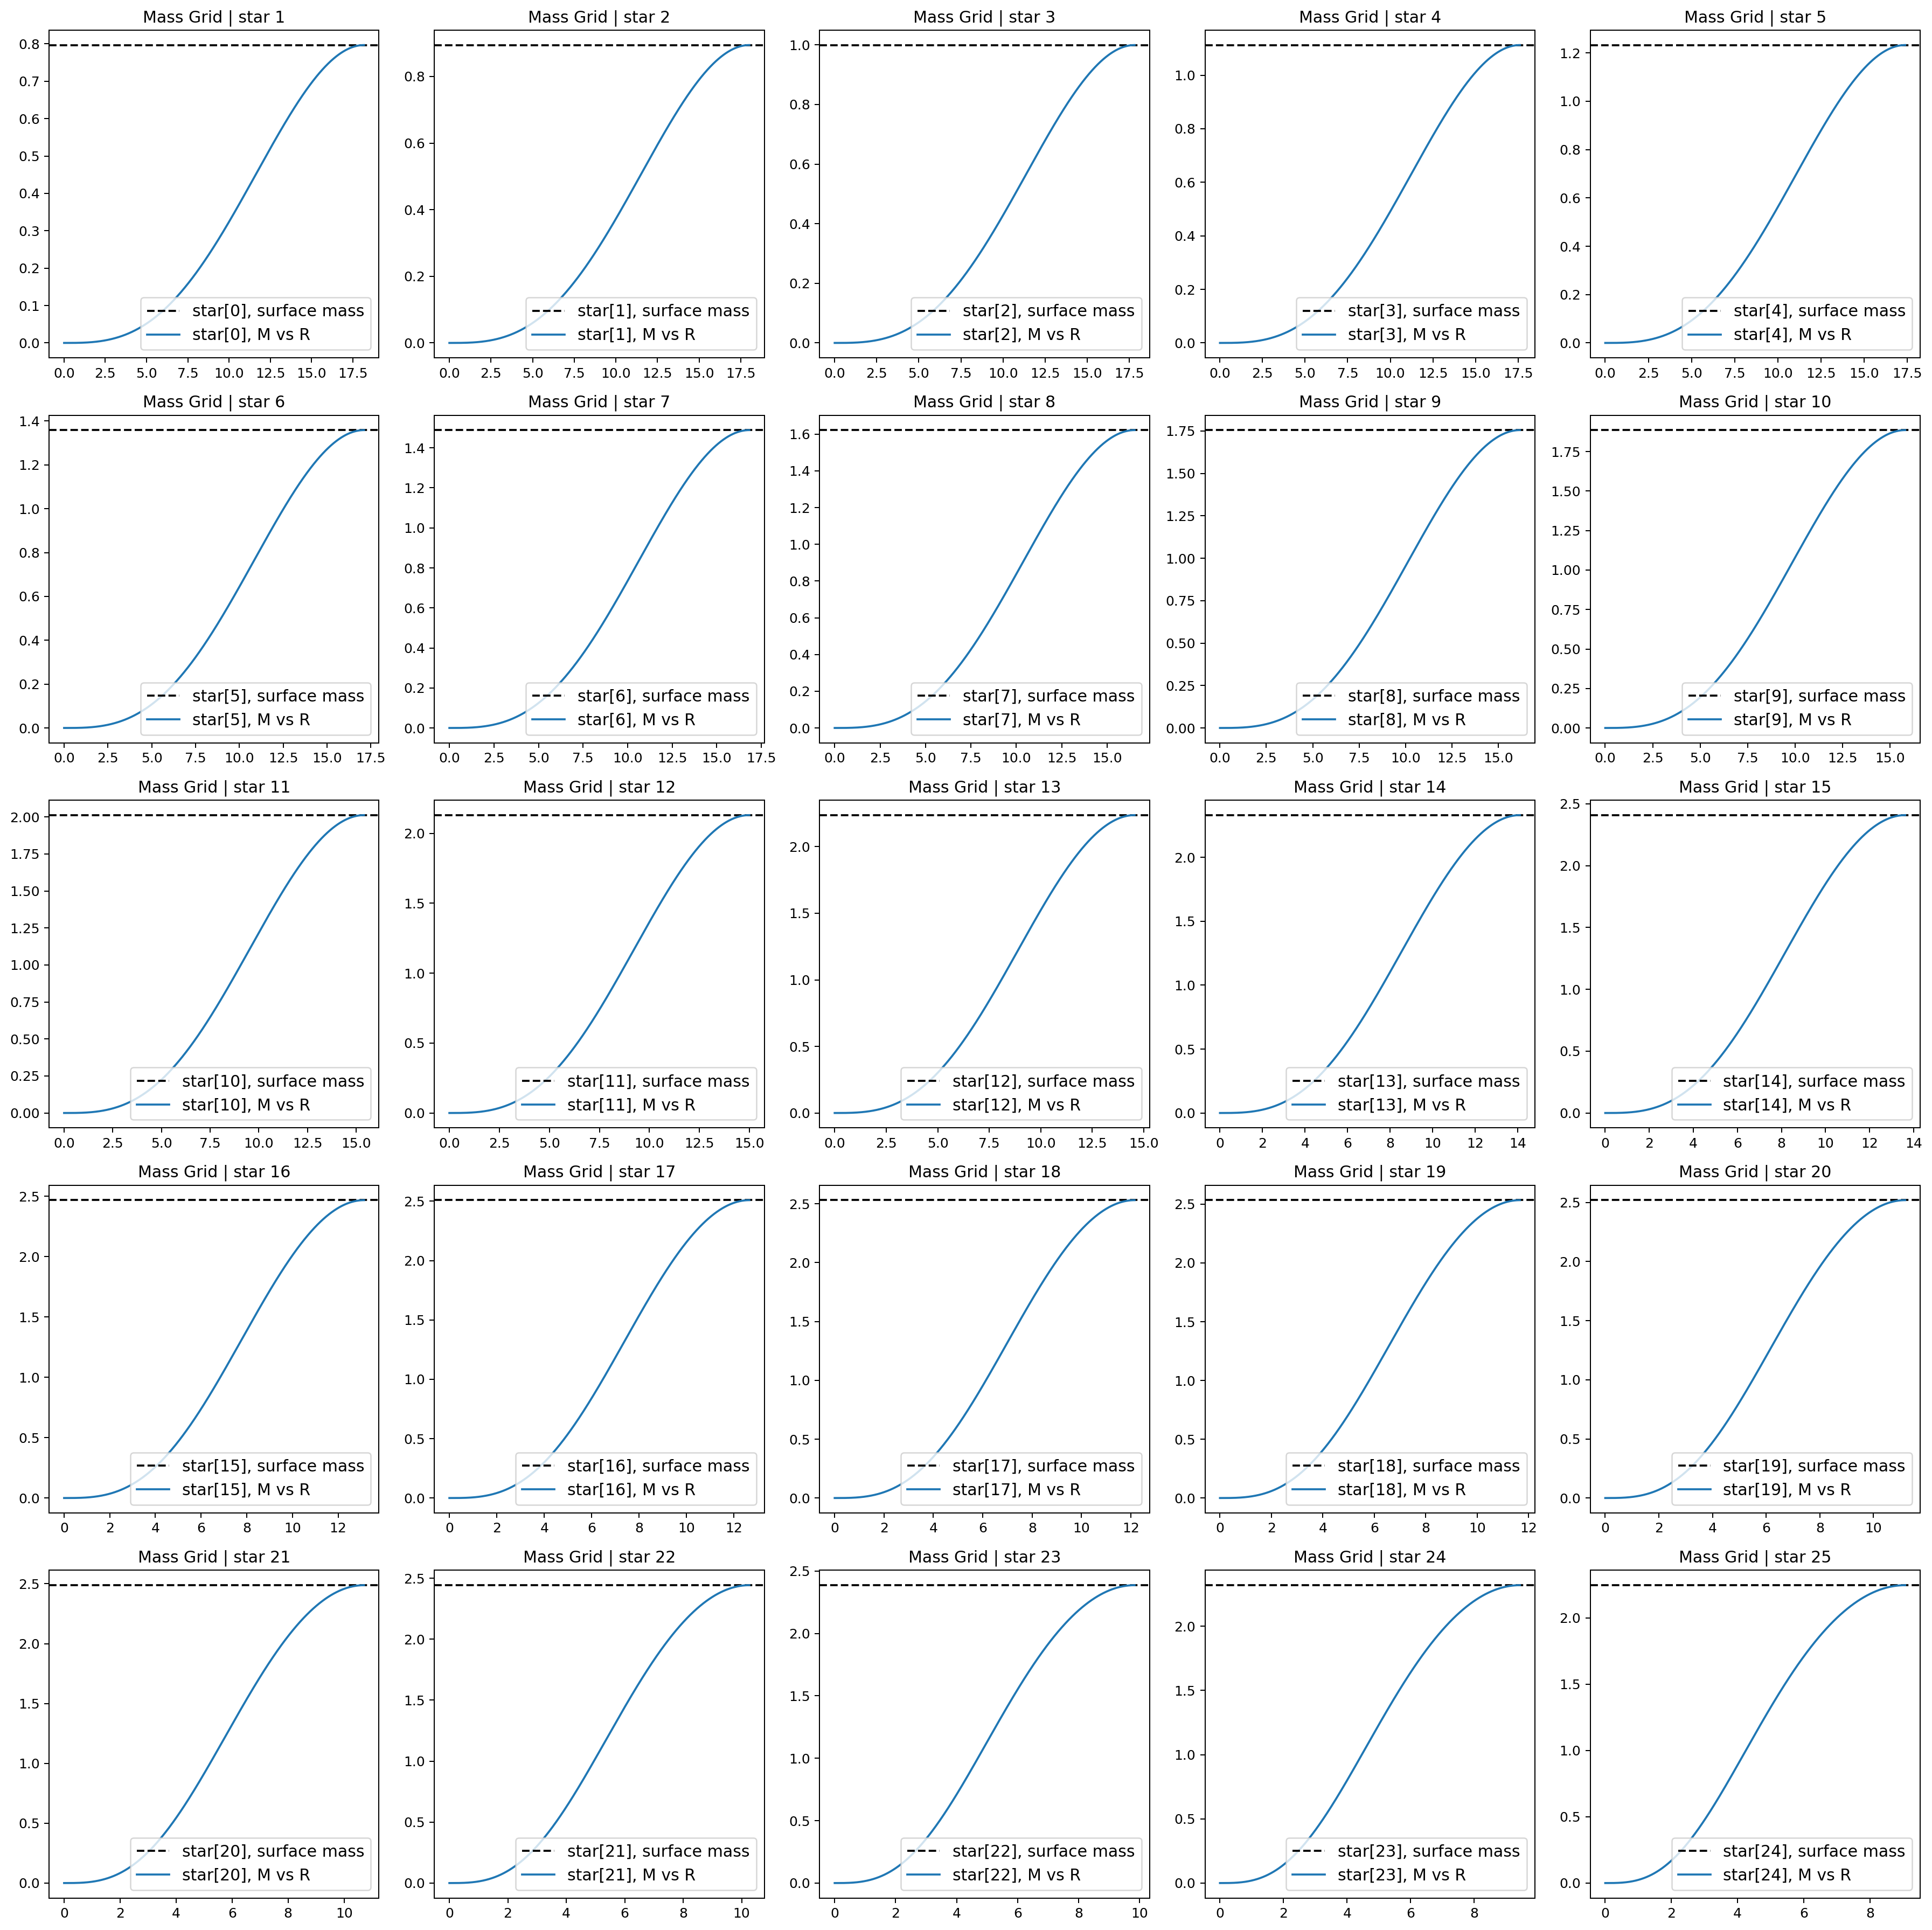

In [77]:
# Mtot on Mass Grid
rows, cols = 5, 5
fig, axs = plt.subplots(rows, cols, figsize=(20, 4 * rows), dpi=180)
axs = np.atleast_1d(axs).reshape(rows, cols)

for i in range(rows * cols):

    ax = axs[i // cols, i % cols]

    MArr = np.array(PMSol_Grid[i])[:,0]
    RArr = np.array(RGrid[i])

    indexSurface = np.min([len(MArr), len(RArr)]) - 1

    ax.set_title(f"Mass Grid | star {i+1}")
    
    ax.axhline(y=I2Sol["records"][i]["M_tot"], ls = "--", color = "black", label=f"star[{i}], surface mass")
    ax.plot(RArr[:indexSurface], MArr[:indexSurface], label=f"star[{i}], M vs R")
    
    ax.legend(fontsize=12, loc=4)
fig.tight_layout()
plt.show()


In [78]:
TDN_Array = np.zeros(n_models)
C_Array = np.zeros(n_models)
TLN_Array = np.zeros(n_models)


for i in range(n_models):
    E0 = E0I0Sol["records"][i]["E0"]
    I2 = I2Sol["records"][i]["I2m"]
    M_tot = I2Sol["records"][i]["M_tot"]
    R_surf = I2Sol["records"][i]["R_surf"]

    H00R = E0I0Sol["records"][i]["hR"]
    H00Rp = E0I0Sol["records"][i]["hRp"]

    C = M_tot/R_surf
    C_Array[i] = C

    K2Arr = K2(C, R_surf, H00R, H00Rp)
    TLN_Array[i] = Love(K2Arr, C)
    TDN_Array[i] = TDN(C, I2, E0)

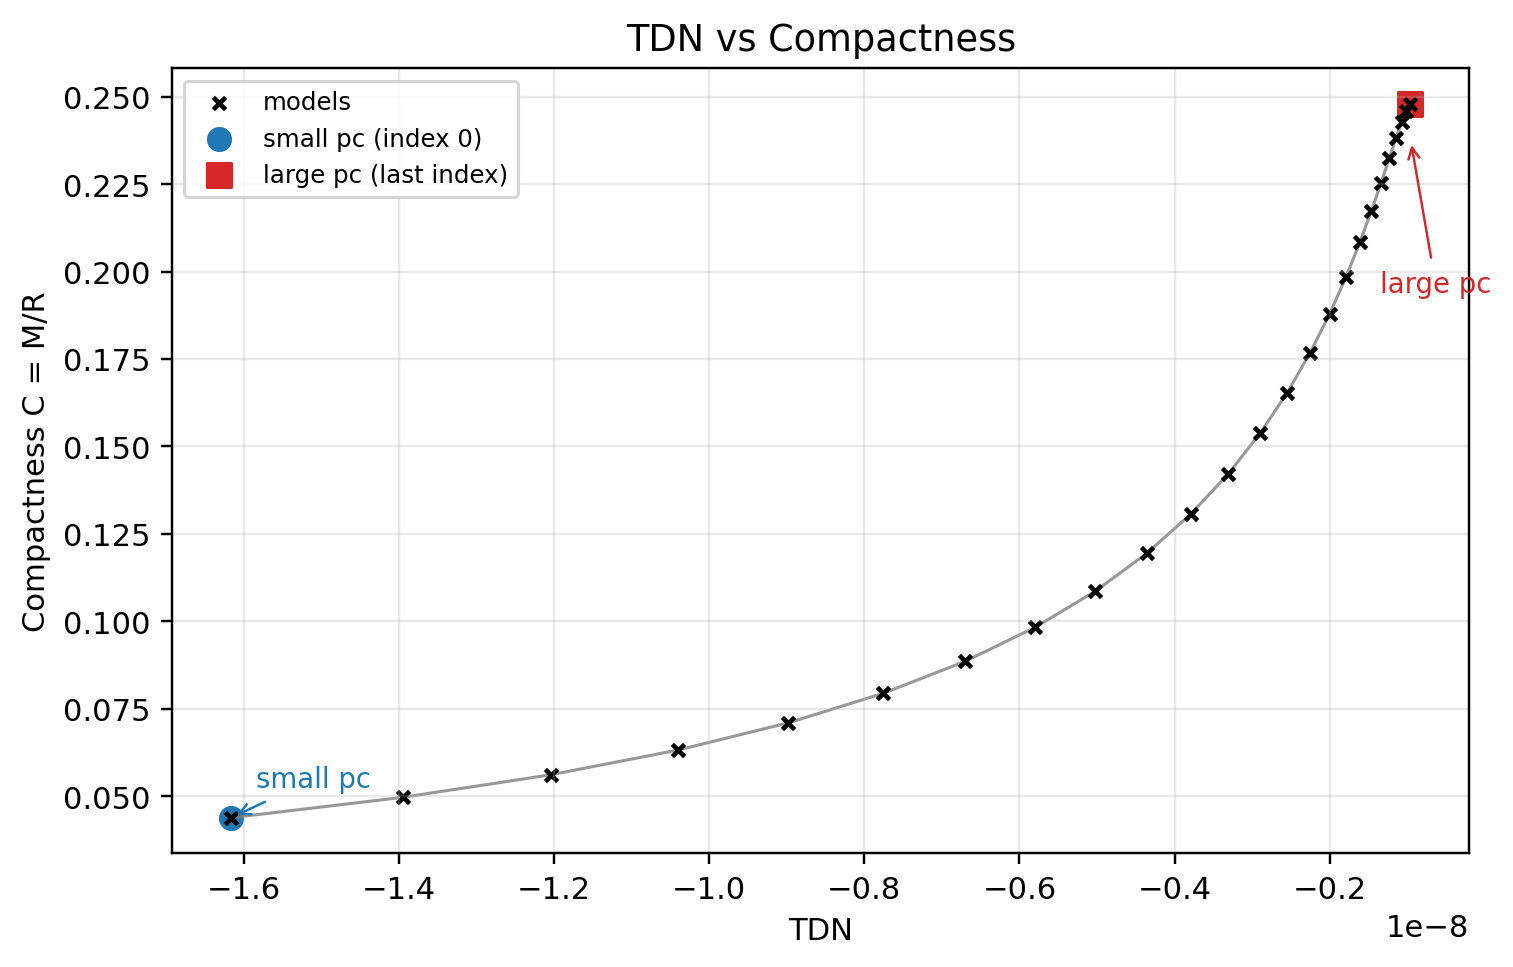

In [102]:
# Plot 1: Compactness C vs TDN, with endpoint pc labels
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=220)

ax.scatter(TDN_Array, C_Array, s=16, c='black', marker='x', label='models')
ax.plot(TDN_Array, C_Array, lw=1.0, color='tab:gray', alpha=0.8, zorder=-10)

# Endpoint pc markers: early index -> small pc, last index -> large pc
i_small = 0
i_large = n_models - 1

ax.scatter(TDN_Array[i_small], C_Array[i_small], s=52, c='tab:blue', marker='o', label='small pc (index 0)', zorder=-200)
ax.scatter(TDN_Array[i_large], C_Array[i_large], s=58, c='tab:red', marker='s', label='large pc (last index)', zorder=-200)

ax.annotate('small pc',
            xy=(TDN_Array[i_small], C_Array[i_small]),
            xytext=(8, 10), textcoords='offset points',
            color='tab:blue', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8, color='tab:blue'))

ax.annotate('large pc',
            xy=(TDN_Array[i_large], C_Array[i_large] - 0.01),
            xytext=(-10, -50), textcoords='offset points',
            color='tab:red', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8, color='tab:red'))

ax.set_xlabel('TDN')
ax.set_ylabel('Compactness C = M/R')
ax.set_title('TDN vs Compactness')
ax.grid(True, alpha=0.28)
ax.legend(loc='best', fontsize=8)
fig.tight_layout()
plt.show()


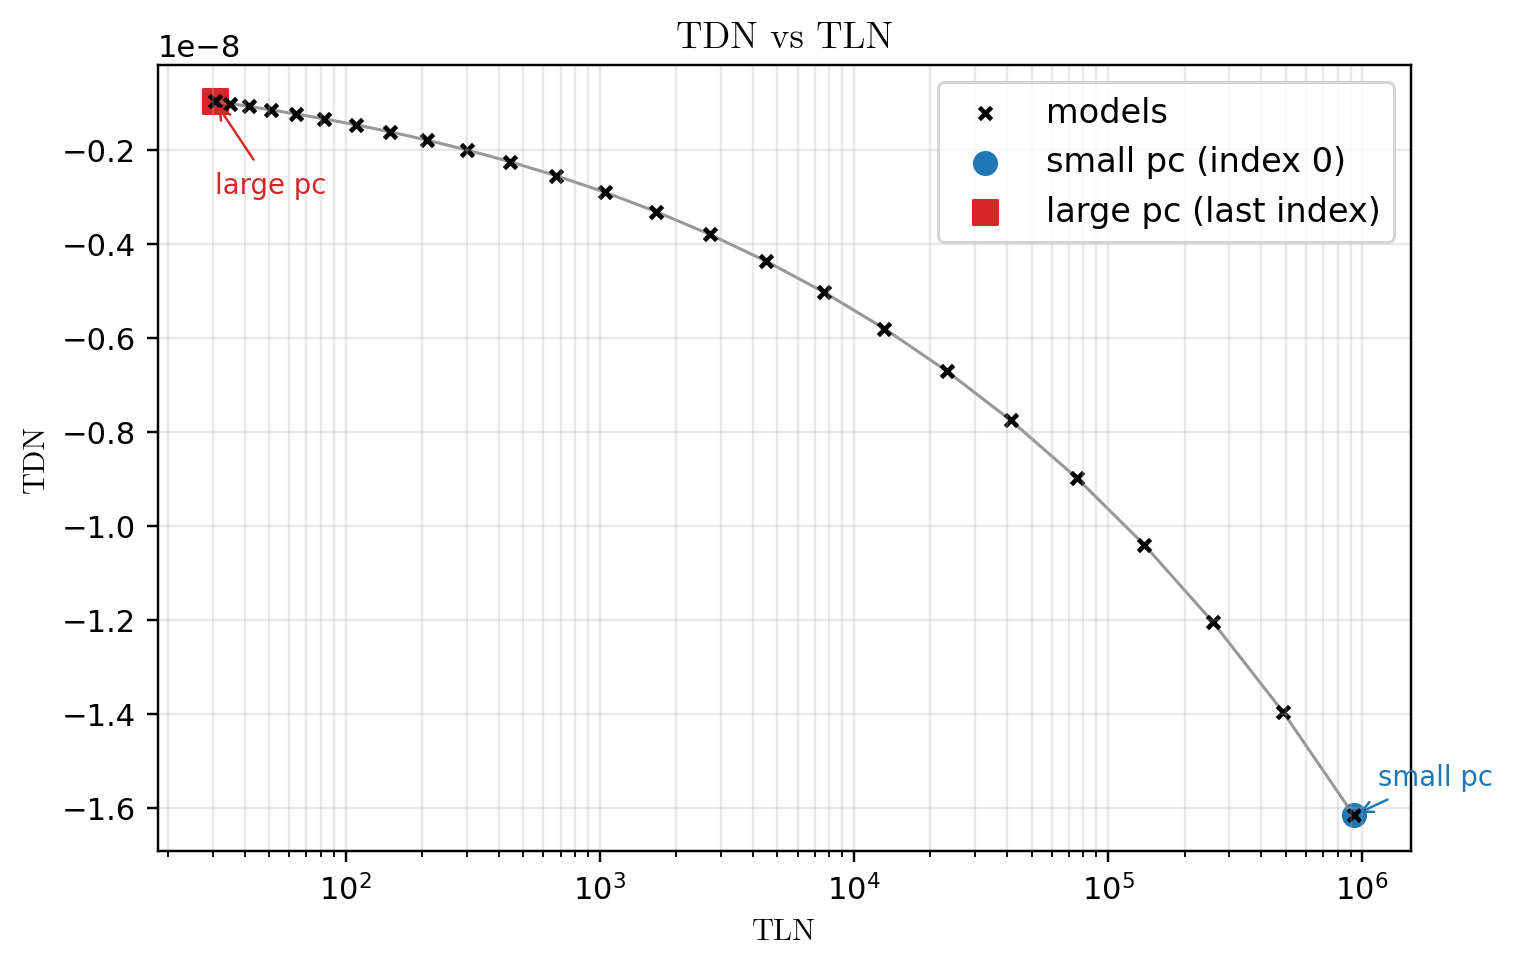

In [97]:
# Plot 2: TDN vs TLN, with endpoint pc labels
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=220)

ax.scatter(TLN_Array, TDN_Array, s=16, c='black', marker='x', label='models')
ax.plot(TLN_Array, TDN_Array, lw=1.0, color='tab:gray', alpha=0.8, zorder=-10)

i_small = 0
i_large = n_models - 1

ax.scatter(TLN_Array[i_small], TDN_Array[i_small], s=52, c='tab:blue', marker='o', label='small pc (index 0)', zorder=-200)
ax.scatter(TLN_Array[i_large], TDN_Array[i_large], s=58, c='tab:red', marker='s', label='large pc (last index)', zorder=-200)

ax.annotate('small pc',
            xy=(TLN_Array[i_small], TDN_Array[i_small]),
            xytext=(8, 10), textcoords='offset points',
            color='tab:blue', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8, color='tab:blue'))

ax.annotate('large pc',
            xy=(TLN_Array[i_large], TDN_Array[i_large]),
            xytext=(0, -30), textcoords='offset points',
            color='tab:red', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8, color='tab:red'))

ax.set_xscale('log')
ax.set_xlabel('TLN', fontfamily="CMU Serif")
ax.set_ylabel('TDN', fontfamily="CMU Serif")
ax.set_title('TDN vs TLN', fontfamily="CMU Serif")
ax.grid(True, which='both', alpha=0.28)
ax.legend(loc='best', fontsize=11)
fig.tight_layout()
plt.show()


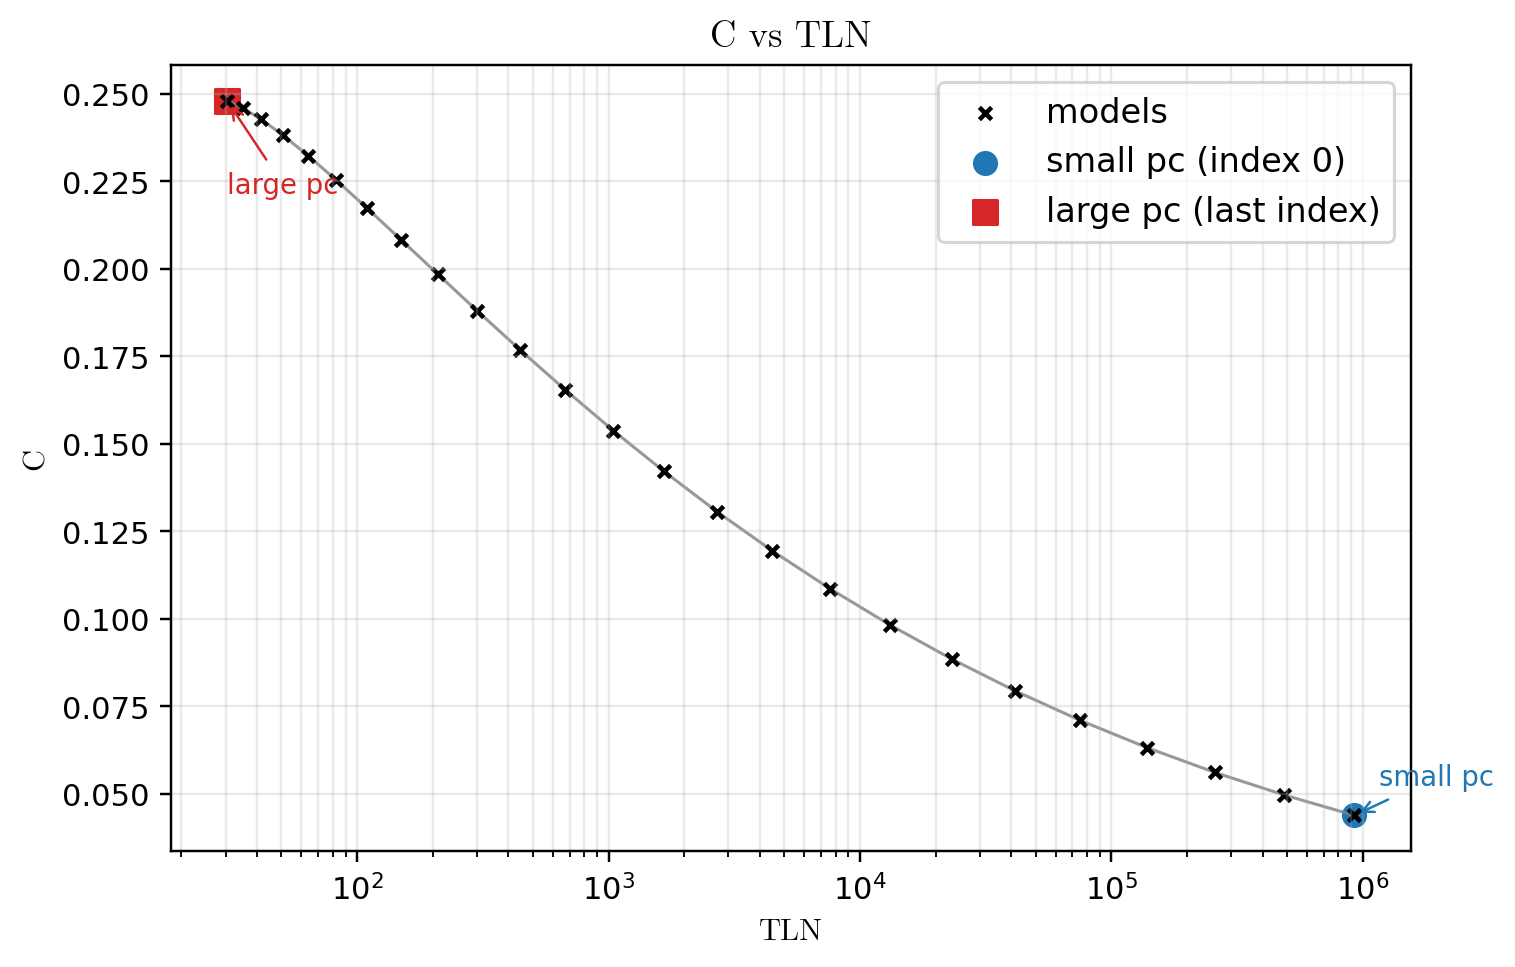

In [103]:
# Plot 2: TDN vs TLN, with endpoint pc labels
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=220)

ax.scatter(TLN_Array, C_Array, s=16, c='black', marker='x', label='models')
ax.plot(TLN_Array, C_Array, lw=1.0, color='tab:gray', alpha=0.8, zorder=-10)

i_small = 0
i_large = n_models - 1

ax.scatter(TLN_Array[i_small], C_Array[i_small], s=52, c='tab:blue', marker='o', label='small pc (index 0)', zorder=-200)
ax.scatter(TLN_Array[i_large], C_Array[i_large], s=58, c='tab:red', marker='s', label='large pc (last index)', zorder=-200)

ax.annotate('small pc',
            xy=(TLN_Array[i_small], C_Array[i_small]),
            xytext=(8, 10), textcoords='offset points',
            color='tab:blue', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8, color='tab:blue'))

ax.annotate('large pc',
            xy=(TLN_Array[i_large], C_Array[i_large]),
            xytext=(0, -30), textcoords='offset points',
            color='tab:red', fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=0.8, color='tab:red'))

ax.set_xscale('log')
ax.set_xlabel('TLN', fontfamily="CMU Serif")
ax.set_ylabel('C', fontfamily="CMU Serif")
ax.set_title('C vs TLN', fontfamily="CMU Serif")
ax.grid(True, which='both', alpha=0.28)
ax.legend(loc='best', fontsize=11)
fig.tight_layout()
plt.show()
